In [2]:
# Hybrid Machine Learning Approach for Anomaly Detection
#Dataset: SWaT (Secure Water Treatment)

#Author: Tahir Ahmad and Hifza Nazir


In [ ]:
# =========================
# 1) Setup: imports & mount drive
# =========================
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, classification_report)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Update this path if your file is in a different folder in Drive
file_path = "/content/drive/MyDrive/Assigment1(Ai_Data-DataSet+reserachPapers)/SWaT_Dataset_Attack_v0.xlsx"
assert os.path.exists(file_path), f"File not found at {file_path}. Please upload or change path."
print("Found file:", file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found file: /content/drive/MyDrive/Assigment1(Ai_Data-DataSet+reserachPapers)/SWaT_Dataset_Attack_v0.xlsx


# Description

In [3]:
## 1. Imports and Environment Setup
## 2. Dataset Loading
## 3. Data Preprocessing
## 4. Random Forest Model
## 5. LSTM Autoencoder
## 6. Hybrid Fusion Strategy
## 7. Evaluation Metrics
## 8. Results and Analysis


In [ ]:
# Try reading the excel file
df = pd.read_excel(file_path, header=1)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns)


# Try to detect label column automatically
label_col_candidates = [c for c in df.columns if c.lower() in ('attack','label','class','is_attack','attacks','state')]
print("Label candidates:", label_col_candidates)
# If no candidate, let user set variable below
if len(label_col_candidates) == 0:
    print("No obvious label column found. Please set 'label_col' manually in the next cell.")
else:
    label_col = label_col_candidates[0]
    print("Using label column:", label_col)


Shape: (449919, 53)


,t_stamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,State
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal



Columns: Index([' t_stamp', 'FIT101', 'LIT101', ' MV101', 'P101', 'P102', ' AIT201',
       'AIT202', 'AIT203', 'FIT201', ' MV201', ' P201', ' P202', 'P203',
       ' P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301',
       'MV302', ' MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402',
       'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501',
       'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504',
       'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602',
       'P603', 'State'],
      dtype='object')
Label candidates: ['State']
Using label column: State


In [ ]:
# If automatic detection didn't find a candidate, set it here (uncomment & edit)
# label_col = 'Attack'   # <<-- uncomment and change if needed

# Validate label_col exists
if 'label_col' not in globals():
    raise Exception("Set `label_col` variable to the name of the label column (e.g. 'Attack').")
if label_col not in df.columns:
    raise Exception(f"Label column '{label_col}' not found in DataFrame columns.")
print("Label column to use:", label_col)


Label column to use: State


In [ ]:
# Copy df to avoid accidental overwrite
data = df.copy()

# Drop timestamp-like columns if present
timestamp_cols = [c for c in data.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
print("Timestamp-like columns:", timestamp_cols)
if timestamp_cols:
    data = data.drop(columns=timestamp_cols)
    print(f"Dropped timestamp columns: {timestamp_cols}")

# Drop fully empty columns
data = data.dropna(axis=1, how='all')

# Drop rows with NA (or optionally fill). Here we drop to keep model simple.
data = data.dropna().reset_index(drop=True)
print("After dropping NAs shape:", data.shape)

# Map label to binary
unique_labels = data[label_col].unique()
print("Unique labels (before mapping):", unique_labels)

def map_labels(x):
    if str(x).lower() in ['normal','0','false','neg','benign','no']:
        return 0
    if str(x).lower() in ['attack','1','true','pos','malicious','yes']:
        return 1
    try:
        # numeric
        return int(x)
    except:
        return 0

data['label_binary'] = data[label_col].apply(map_labels)
print("Label distribution:\n", data['label_binary'].value_counts())


Timestamp-like columns: []
After dropping NAs shape: (449919, 53)
Unique labels (before mapping): ['Normal' 'Attack' 'A ttack']
Label distribution:
 label_binary
0    395335
1     54584
Name: count, dtype: int64


In [ ]:
# Drop original label columns from features
X = data.drop(columns=[label_col, 'label_binary'])
y = data['label_binary'].copy()

# If any non-numeric columns remain, try to convert or drop them
non_num = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric feature columns:", non_num)
if non_num:
    print("Attempting to convert non-numeric columns to numeric (simple).")
    for c in non_num:
        X[c] = pd.to_numeric(X[c], errors='coerce')
    # drop rows that still have NA
    na_rows = X.isna().any(axis=1)
    if na_rows.sum() > 0:
        print(f"Dropping {na_rows.sum()} rows with non-convertible values.")
        X = X[~na_rows].reset_index(drop=True)
        y = y[~na_rows].reset_index(drop=True)

print("Final features shape:", X.shape)


Non-numeric feature columns: [' t_stamp']
Attempting to convert non-numeric columns to numeric (simple).
Dropping 449919 rows with non-convertible values.
Final features shape: (0, 52)


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels in y:", np.unique(y))
print("Counts:", np.bincount(y))


X shape: (0, 52)
y shape: (0,)
Unique labels in y: []
Counts: []


In [ ]:
# 1. Remove timestamp column
df = df.drop(columns=['t_stamp'])

# 2. Fix State column (remove NaN rows)
df = df.dropna(subset=['State'])

# 3. Convert State to int
df['State'] = df['State'].astype(int)

# 4. Remove other NaN values from feature columns
df = df.dropna()

# Split data
X = df.drop(columns=['State'])
y = df['State']

print("Final shapes:", X.shape, y.shape)

# Train–test split
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# LSTM gets only normal samples
X_train_for_lstm = X_train_full[y_train_full == 0].copy()

# Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_rf = StandardScaler()
X_train_rf = scaler_rf.fit_transform(X_train_full)
X_test_rf = scaler_rf.transform(X_test)

scaler_lstm = MinMaxScaler()
X_train_lstm = scaler_lstm.fit_transform(X_train_for_lstm)
X_test_lstm = scaler_lstm.transform(X_test)

print("RF shapes:", X_train_rf.shape, X_test_rf.shape)
print("LSTM shapes:", X_train_lstm.shape, X_test_lstm.shape)


Final shapes: (449882, 51) (449882,)
RF shapes: (359905, 51) (89977, 51)
LSTM shapes: (316238, 51) (89977, 51)


In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train_rf, y_train_full)

# Predict on test set
y_pred_rf = rf.predict(X_test_rf)
y_prob_rf = rf.predict_proba(X_test_rf)[:,1]

print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf))
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, zero_division=0)
rf_rec = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)
print(f"RF Acc: {rf_acc:.4f}, Prec: {rf_prec:.4f}, Rec: {rf_rec:.4f}, F1: {rf_f1:.4f}")


Random Forest classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79060
           1       1.00      1.00      1.00     10917

    accuracy                           1.00     89977
   macro avg       1.00      1.00      1.00     89977
weighted avg       1.00      1.00      1.00     89977

RF Acc: 0.9998, Prec: 0.9993, Rec: 0.9994, F1: 0.9993


In [ ]:
# LSTM needs 3D input: (samples, timesteps, features)
# We'll set timesteps = 1 (frame-wise autoencoder)
timesteps = 1
n_features = X_train_lstm.shape[1]

X_train_lstm_3d = X_train_lstm.reshape((X_train_lstm.shape[0], timesteps, n_features))
X_test_lstm_3d = X_test_lstm.reshape((X_test_lstm.shape[0], timesteps, n_features))

print("LSTM train shape:", X_train_lstm_3d.shape, "LSTM test shape:", X_test_lstm_3d.shape)


LSTM train shape: (316238, 1, 51) LSTM test shape: (89977, 1, 51)


In [ ]:
# Build LSTM Autoencoder
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

# Use a small model to keep training quick on Colab
latent_dim = max(8, n_features // 2)

inputs = Input(shape=(timesteps, n_features))
# encoder
encoded = LSTM(latent_dim, activation='relu', return_sequences=False)(inputs)
# bottleneck -> repeat
repeated = RepeatVector(timesteps)(encoded)
# decoder
decoded = LSTM(latent_dim, activation='relu', return_sequences=True)(repeated)
outputs = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 51)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 25)             │         7,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 25)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 25)          │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 51)          │         1,326 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,126 (55.18 KB)

 Trainable params: 14,126 (55.18 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the autoencoder
history = autoencoder.fit(
    X_train_lstm_3d, X_train_lstm_3d,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)


Epoch 1/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 0.0290 - val_loss: 9.3731e-04
Epoch 2/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 6.9681e-04 - val_loss: 4.4651e-04
Epoch 3/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 3.7666e-04 - val_loss: 2.9407e-04
Epoch 4/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2.7238e-04 - val_loss: 2.6373e-04
Epoch 5/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2.5343e-04 - val_loss: 2.8826e-04
Epoch 6/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 2.4539e-04 - val_loss: 2.3700e-04
Epoch 7/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2.3845e-04 - val_loss: 2.6025e-04
Epoch 8/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2.3465e-04 - val_loss: 2.5986e-04
Epoch 9/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2.3619e-04 - val_loss: 2.3598e-04
Epoch 10/30
4448/4448 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2.3332e-04 - val_loss: 2.4668e-04
Epoch 11/30
4448/4448 ━━━━━━━━━━━

In [ ]:
# Compute reconstruction MSE on test set
X_test_pred = autoencoder.predict(X_test_lstm_3d)
mse = np.mean(np.power(X_test_lstm_3d - X_test_pred, 2), axis=(1,2))  # per-sample MSE

# Determine threshold from training normal reconstruction errors (use mean+2*std or percentile)
X_train_pred = autoencoder.predict(X_train_lstm_3d)
mse_train = np.mean(np.power(X_train_lstm_3d - X_train_pred, 2), axis=(1,2))
threshold = np.percentile(mse_train, 99)  # conservative
print("Train MSE mean", mse_train.mean(), "std", mse_train.std())
print("Selected threshold (99th percentile of train MSE):", threshold)

# Get binary predictions from MSE > threshold
y_pred_lstm = (mse > threshold).astype(int)

# Evaluate LSTM predictions (note: LSTM was only trained on normal so it may be good at detecting unknown attacks)
print("LSTM (autoencoder) results on test set:")
print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm))
lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_prec = precision_score(y_test, y_pred_lstm, zero_division=0)
lstm_rec = recall_score(y_test, y_pred_lstm, zero_division=0)
lstm_f1 = f1_score(y_test, y_pred_lstm, zero_division=0)


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
Train MSE mean 0.00023723744548930257 std 0.0013646777081681956
Selected threshold (99th percentile of train MSE): 0.004279345565713262
LSTM (autoencoder) results on test set:
Accuracy: 0.9600120030674506
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     79060
           1       0.91      0.74      0.82     10917

    accuracy                           0.96     89977
   macro avg       0.94      0.87      0.90     89977
weighted avg       0.96      0.96      0.96     89977



In [ ]:
# Method B: Weighted fusion
# Normalize LSTM mse into 0-1 anomaly score (higher means more anomalous)
mse_norm = (mse - mse.min()) / (mse.max() - mse.min() + 1e-12)
# RF probability (already 0-1)
rf_prob = y_prob_rf

# Weighted sum: w1 * rf_prob + w2 * mse_norm
w_rf = 0.5
w_lstm = 0.5
fused_score = w_rf * rf_prob + w_lstm * mse_norm

# Choose threshold using simple heuristic or ROC; here we choose the mean as baseline
threshold_fused = fused_score.mean() + 0.0 * fused_score.std()
y_pred_fused = (fused_score >= threshold_fused).astype(int)

print("Hybrid Weighted Fusion results (weights rf=0.5, lstm=0.5):")
print(classification_report(y_test, y_pred_fused))
hy_w_acc = accuracy_score(y_test, y_pred_fused)
hy_w_prec = precision_score(y_test, y_pred_fused, zero_division=0)
hy_w_rec = recall_score(y_test, y_pred_fused, zero_division=0)
hy_w_f1 = f1_score(y_test, y_pred_fused, zero_division=0)


Hybrid Weighted Fusion results (weights rf=0.5, lstm=0.5):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     79060
           1       0.95      1.00      0.98     10917

    accuracy                           0.99     89977
   macro avg       0.98      1.00      0.99     89977
weighted avg       0.99      0.99      0.99     89977



In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'LSTM Autoencoder', 'Hybrid Weighted'],
    'Accuracy': [rf_acc, lstm_acc, hy_w_acc],
    'Precision': [rf_prec, lstm_prec, hy_w_prec],
    'Recall': [rf_rec, lstm_rec, hy_w_rec],
    'F1': [rf_f1, lstm_f1, hy_w_f1]
})

display(results.style.format({c: "{:.4f}" for c in results.columns if c!='Model'}))


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.9998,0.9993,0.9994,0.9993
1,LSTM Autoencoder,0.9600,0.9114,0.7426,0.8184
2,Hybrid Weighted,0.9940,0.9529,1.0000,0.9759


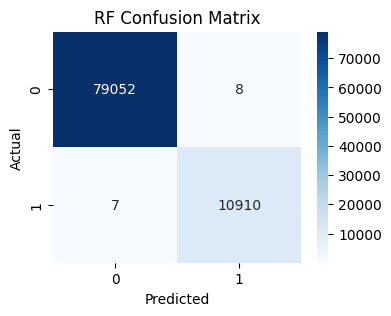

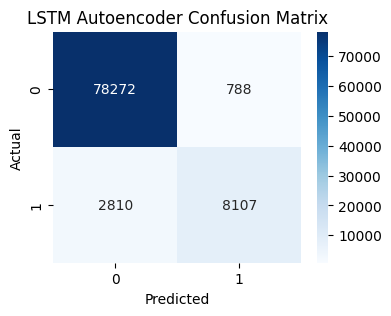

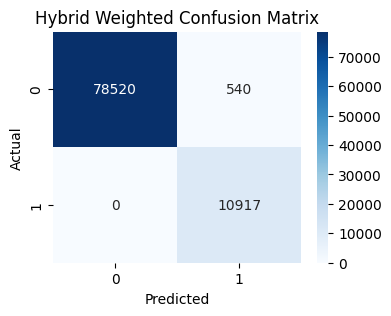

In [ ]:
# Confusion matrices
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_confusion(y_test, y_pred_rf, 'RF Confusion Matrix')
plot_confusion(y_test, y_pred_lstm, 'LSTM Autoencoder Confusion Matrix')
plot_confusion(y_test, y_pred_fused, 'Hybrid Weighted Confusion Matrix')



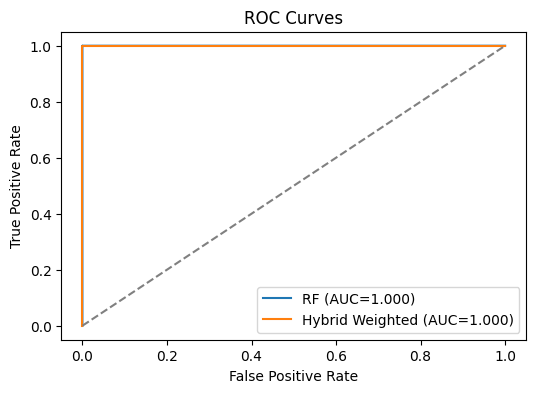

In [ ]:
# ROC Curves: RF and Hybrid weighted (only these yield continuous scores)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_fused, tpr_fused, _ = roc_curve(y_test, fused_score)
auc_fused = roc_auc_score(y_test, fused_score)

plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={auc_rf:.3f})')
plt.plot(fpr_fused, tpr_fused, label=f'Hybrid Weighted (AUC={auc_fused:.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


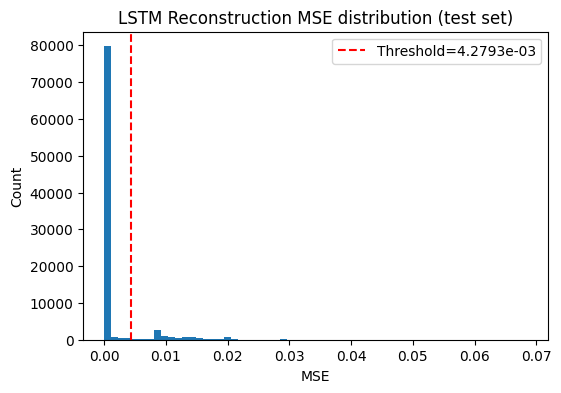

In [ ]:
# Histogram of LSTM reconstruction errors
plt.figure(figsize=(6,4))
plt.hist(mse, bins=60)
plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold={threshold:.4e}')
plt.title('LSTM Reconstruction MSE distribution (test set)')
plt.xlabel('MSE')
plt.ylabel('Count')
plt.legend()
plt.show()


In [ ]:
# Example: save RF model and scalers (use joblib)
import joblib
save_dir = "/content/drive/MyDrive/swat_model_outputs"
os.makedirs(save_dir, exist_ok=True)
joblib.dump(rf, os.path.join(save_dir, "rf_model.joblib"))
joblib.dump(scaler_rf, os.path.join(save_dir, "scaler_rf.joblib"))
joblib.dump(scaler_lstm, os.path.join(save_dir, "scaler_lstm.joblib"))

# Save autoencoder weights
autoencoder.save(os.path.join(save_dir, "lstm_autoencoder.h5"))

# Save results table
results.to_csv(os.path.join(save_dir, "results_summary.csv"), index=False)
print("Saved models and results to", save_dir)


Saved models and results to /content/drive/MyDrive/swat_model_outputs
